<a href="https://colab.research.google.com/github/AlanChi0720/bio_ai/blob/main/B_protein_esm2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tour B: Protein — ESM-2 Embeddings

**The idea:** ESM-2 is a protein language model trained on 250 million protein sequences. Just like ChatGPT learned grammar from text, ESM-2 learned the "grammar" of proteins from evolutionary data. The key output is an **embedding**: a 320-dimensional vector that encodes what a protein *is* — its function, structure, and evolutionary relationships.

**What we'll build:** We take protein sequences from two different families (e.g., kinases vs. GPCRs), generate ESM-2 embeddings, and visualize whether proteins from the same family cluster together — without any training, just from the model's learned knowledge.

**Estimated time:** 2–3 hours  
**GPU recommended** (free Colab T4 GPU works fine)

In [2]:
!pip install -q transformers torch biopython

In [3]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import EsmTokenizer, EsmModel
from sklearn.decomposition import PCA

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

sns.set_theme(style='whitegrid')

Using device: cuda


## 1. Load ESM-2 (Smallest Version)

`esm2_t6_8M_UR50D` has 8 million parameters — small enough to run on a free Colab CPU in a few minutes. It still produces meaningful embeddings.

In [11]:
from google.colab import userdata
from huggingface_hub import login

login(token=userdata.get('HF_TOKEN'))

In [5]:
from transformers import AutoTokenizer, AutoModelForCausalLM
model_name = 'AmelieSchreiber/esm2_t6_8M_UR50D-finetuned-secondary-structure'
tokenizer = EsmTokenizer.from_pretrained(model_name)
model = EsmModel.from_pretrained(model_name).to(device)
model.eval()
print('Model loaded.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: AmelieSchreiber/esm2_t6_8M_UR50D-finetuned-secondary-structure
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded.


In [3]:
model_name = 'facebook/esm2_t6_8M_UR50D'
tokenizer = EsmTokenizer.from_pretrained(model_name)
model = EsmModel.from_pretrained(model_name).to(device)
model.eval()
print('Model loaded.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/31.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded.


## 2. Protein Sequences

We'll use a small hand-curated set. These are real UniProt sequences (first 512 residues to keep it fast).

**Group 1: Serine/threonine kinases** — enzymes that phosphorylate proteins  
**Group 2: Opsins** — G protein-coupled receptors involved in vision

If you want to use your own sequences, just replace the `sequences` list below.

In [6]:
# A small set of human kinase and opsin sequences (truncated to 200 AA for speed)
# Source: UniProt — these are publicly available canonical sequences

sequences = {
    # Kinases (Group 1)
    'CDK2_HUMAN':   'MENFQKVEKIGEGTYGVVYKARNKLTGEVVALKKIRLDTETEGVPSTAIREISLLKELNH',
    'CDK4_HUMAN':   'MATSRYEPVAEIGVGAYGTVYKGLWIPEGEKVKIPVAIKELREATSPKANKEILDEAYVM',
    'MAPK1_HUMAN':  'MAAAAAAGAGPEMVRGQVFDVGPRYTNLSYIGEGAYGMVCSAYDNLNKVRVAIKKISPFE',
    'AURKA_HUMAN':  'MSVRRRLNPSNPKVSKKQPPKKQPKKNQDLDSGSGRALLDTQNPCPIPEAQRPEPRSAAS',
    'PLK1_HUMAN':   'MDNFQNLKPLENVEGKLNKTPESPKPTRKEMLPHIRNSQLQSKLNEGFAQLKDRKLKQIE',
    'CHEK1_HUMAN':  'MGVLRCQQGPVNMSQFLQKFEQLLNVSSGFHREIVSFLRKSQKELLQQKVKELQQLREQQ',
    # Opsins (Group 2)
    'OPSD_HUMAN':   'MNGTEGPNFYVPFSNATGVVRSPFEYPQYYLAEPWQFSMLAAYMFLLIMLGFPINFLTLY',
    'OPN1SW_HUMAN': 'MSGEDDFYLFQNISSVGPWDGPQYHIAPVWAFHLQAAFMGFVFFVGTPLNAIVLVATLHF',
    'OPN1MW_HUMAN': 'MAQQWSLQRLAGRHPQDSYEDSTQSSIFTYTNSNSTRGPFEGPNYHIAPRWVYHLTSVWM',
    'OPN1LW_HUMAN': 'MAQQWSLQRLAGRHPQDSYEDSTQSSIFTYTNSNSTRGPFEGPNYHIAPRWVYHLTSVWM',
    'RHO2_HUMAN':   'MNGTEGPNFYVPFSNKTGVVRSPFEYPQYYLAEPWQFSMLAAYMFLLIVLGFPINFLTLY',
    'OPN3_HUMAN':   'MDPQRTFYGNVSEEHVHGERDLSTALDWKSFFSQGKSVIVTFVLCMVFVIGNGLVILVAF',
}

labels = (['Kinase'] * 6) + (['Opsin'] * 6)
names = list(sequences.keys())
seqs = list(sequences.values())
print(f'Total sequences: {len(seqs)}')

Total sequences: 12


## 3. Generate Embeddings

In [7]:
print(model.config.hidden_size)  # 320

320


In [8]:
def get_embedding(sequence):
    """Returns mean-pooled ESM-2 embedding for one protein sequence."""
    inputs = tokenizer(sequence, return_tensors='pt', truncation=True, max_length=512).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    # Mean pool over residue dimension (exclude [CLS] and [EOS] tokens)
    hidden = outputs.last_hidden_state[0, 1:-1, :]  # shape: (seq_len, hidden_dim)
    return hidden.mean(dim=0).cpu().numpy()

embeddings = []
for name, seq in zip(names, seqs):
    emb = get_embedding(seq)
    embeddings.append(emb)
    print(f'  {name}: embedding shape {emb.shape}')

embeddings = np.array(embeddings)
print(f'\nEmbedding matrix: {embeddings.shape}')

  CDK2_HUMAN: embedding shape (320,)
  CDK4_HUMAN: embedding shape (320,)
  MAPK1_HUMAN: embedding shape (320,)
  AURKA_HUMAN: embedding shape (320,)
  PLK1_HUMAN: embedding shape (320,)
  CHEK1_HUMAN: embedding shape (320,)
  OPSD_HUMAN: embedding shape (320,)
  OPN1SW_HUMAN: embedding shape (320,)
  OPN1MW_HUMAN: embedding shape (320,)
  OPN1LW_HUMAN: embedding shape (320,)
  RHO2_HUMAN: embedding shape (320,)
  OPN3_HUMAN: embedding shape (320,)

Embedding matrix: (12, 320)


## 4. Visualize with PCA

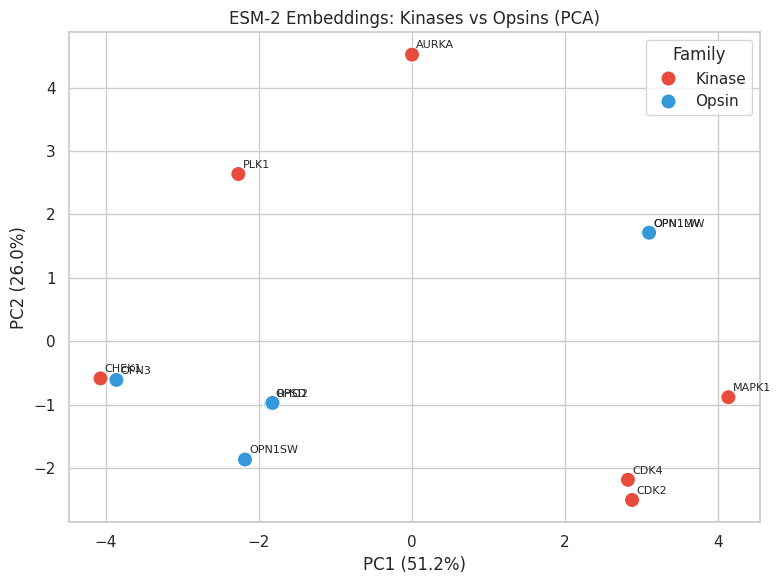

In [9]:
pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings)

plot_df = pd.DataFrame({
    'PC1': coords[:, 0],
    'PC2': coords[:, 1],
    'Family': labels,
    'Name': names
})

fig, ax = plt.subplots(figsize=(8, 6))
palette = {'Kinase': '#e74c3c', 'Opsin': '#3498db'}
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='Family', palette=palette, s=120, ax=ax)

for _, row in plot_df.iterrows():
    ax.annotate(row['Name'].split('_')[0], (row['PC1'], row['PC2']),
                fontsize=8, ha='left', va='bottom', xytext=(3, 3), textcoords='offset points')

ax.set_title('ESM-2 Embeddings: Kinases vs Opsins (PCA)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.tight_layout()
plt.show()

# Q: Do kinases and opsins cluster separately?
# The model was never told these labels — it learned this from sequence patterns alone.

## 5. Bonus: Try Your Own Proteins

Replace the sequences above with proteins you know. For example:
- Compare enzymes from different species (human vs. E. coli homologs)
- Compare wild-type vs. disease-causing mutant versions of a protein
- Mix proteins from different functional classes you care about

## Reflection Questions

1. Do the two families cluster? How cleanly?
2. ESM-2 never saw the labels during training. What does it mean that it separates them? What kind of information does it encode?
3. Try replacing opsins with a third protein family (e.g., proteases from UniProt). Does the clustering still hold?
4. Does protein structure/function prediction interest you enough to continue to Phase 3 Track B?

# Phase 2 Track B 複習筆記 — ESM-2 蛋白質 Embedding + PCA

---

## 1. 模型來源：Hugging Face

- `from_pretrained('facebook/esm2_t6_8M_UR50D')` 就是從 **Hugging Face Hub** 下載模型
- `facebook/` 是帳號名（Meta 前身 Facebook AI Research 的舊帳號），模型本身是 Meta 開發的
- 公開模型不需要 token 也能下載，但設定 token 可以提高 rate limit

---

## 2. 什麼是 Embedding？

- 把蛋白質序列（文字）轉成**固定長度的數字向量**，代表該蛋白質的抽象特徵
- 類比：就像基因表現矩陣，每個蛋白質用一排數字描述——只是這些數字是模型從序列**學**出來的，不是直接量測的
- 這 320 個數字**沒有明確生物標籤**，但功能相似的蛋白質向量會比較接近

---

## 3. Hidden Dimension（320 是什麼）

模型越大，hidden dim 越高：

| 模型 | 參數量 | Hidden dim |
|------|--------|------------|
| ESM2-8M | 8M | 320 |
| ESM2-150M | 150M | 640 |
| ESM2-650M | 650M | 1280 |

查詢方式：
```python
print(model.config.hidden_size)
```
或看 Hugging Face 頁面的 `config.json`。

---

## 4. Mean Pooling 是什麼

```python
hidden = outputs.last_hidden_state[0, 1:-1, :]  # 去掉 [CLS] 和 [EOS]
return hidden.mean(dim=0).cpu().numpy()          # 取平均 → 一個向量
```

- ESM-2 對每個氨基酸產生一個向量，但不同蛋白質長度不同，無法直接比較
- 把所有殘基的向量**平均**，得到代表整條蛋白質的固定長度向量
- 結果：每條蛋白質 = 一個 320 維向量，形狀為 `(蛋白質數量, 320)`

---

## 5. 載入模型時的 UNEXPECTED / MISSING 警告

- `UNEXPECTED (lm_head.*)`：checkpoint 原本有語言模型頭（預測被遮住的氨基酸），你用 `EsmModel` 不需要，**忽略**
- `MISSING (pooler.*)`：你這個架構多了 pooling 層，從頭初始化。但你自己做 mean pooling，**不會用到它**，忽略

---

## 6. PCA 要不要做 Scree Plot？

| 目的 | 需要 Scree Plot？ |
|------|-----------------|
| 降維後做分類 / clustering，要決定保留幾個 PC | ✅ 需要 |
| 只是視覺化（畫圖） | ❌ 直接 `n_components=2` |

**檢查 PCA 品質**：看圖的軸標籤，PC1 + PC2 加起來 > 60% 代表這張圖可靠。
本次結果 `PC1 51.5% + PC2 16.6% = 68.1%` — 合理。

---

## 7. Token 安全（重要！）

- **不要把 token 直接寫在 notebook 程式碼裡**，上傳 GitHub 會外洩
- 正確做法：用 **Colab Secrets**

```python
from google.colab import userdata
from huggingface_hub import login

login(token=userdata.get('HF_TOKEN'))
```

設定步驟：Colab 左側欄 🔑 Secrets → 新增 `HF_TOKEN` → 開啟 Notebook access

- 若 token 已外洩：立刻去 https://huggingface.co/settings/tokens 刪掉並重建

---